In [1]:
# library(Seurat)
# library(dplyr)
# library(clusterProfiler)

# rgc <- readRDS('data/snRNA_data/RGC.rds')
# gmt_files <- list.files('data/snRNA_data/RGC_module_score/gmt_files',full.names = TRUE)

# all_gmt_df <- lapply(gmt_files, read.gmt) %>% bind_rows()
# pathway_list <- split(all_gmt_df$gene, all_gmt_df$term)
# pathway_list <- lapply(pathway_list,function(x){intersect(x, rownames(rgc))})

# for (i in seq_along(pathway_list)) {
#   p_name <- names(pathway_list)[i]
#   rgc <- AddModuleScore(object = rgc, features = list(pathway_list[[i]]), name = p_name, ctrl = 100)
#   colnames(rgc@meta.data)[ncol(rgc@meta.data)] <- strsplit(p_name,split='GOBP_')[[1]][2]
# }

# ss <- data.frame(condition=NULL,mean_scaled_score=NULL,pathway=NULL)
# control_group <- 'Contralateral'
# test_groups <- c('COH_2w','COH_4w','COH_8w')
# pathways <- sapply(names(pathway_list),function(x){strsplit(x,split='GOBP_')[[1]][2]})

# for(p in pathways){
#     rgc@meta.data$Scaled_Score <- scale(rgc@meta.data[[p]])
#     summary_df <- rgc@meta.data %>%  group_by(condition) %>%  summarise(mean_scaled_score = mean(Scaled_Score)) %>% mutate(pathway=rep(p,times=4))
#     ss <- rbind(ss,summary_df)
# }

# ss$pvalue <- NA

# for(p in pathways){
#     p_value <- c(1)
#     for (group in test_groups) {
#       control_scores <- rgc@meta.data[rgc$condition == control_group, p]
#       test_scores <- rgc@meta.data[rgc$condition == group, p]
#       res <- wilcox.test(test_scores, control_scores)
#       p_value <- c(p_value,res$p.value)
#     }
#     ss$pvalue[ss$pathway %in% p] <- p_value
# }

# write.csv(ss,'data/snRNA_data/RGC_module_score/heatmap.csv',row.names=FALSE)

In [2]:
library(tidyverse)
library(pheatmap)
library(reshape2)

── Attaching core tidyverse packages ──────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [3]:
ss <- read.csv('data/snRNA_data/RGC_module_score/heatmap.csv')

In [4]:
ss$condition <- factor(ss$condition, levels = c("Contralateral", "COH_2w", "COH_4w", "COH_8w"))

In [5]:
value_mat <- acast(ss, pathway ~ condition, value.var = "mean_scaled_score")

In [6]:
pval_mat <- acast(ss, pathway ~ condition, value.var = "pvalue")

In [8]:
get_sig_tags <- function(p) {
  ifelse(p < 0.001, "***",
    ifelse(p < 0.01, "**",
      ifelse(p < 0.05, "*", "")))
}

In [9]:
display_mat <- apply(pval_mat, c(1, 2), get_sig_tags)

In [10]:
my_color = colorRampPalette(c("#78BBE2", "white", "#D6604D"))(100)

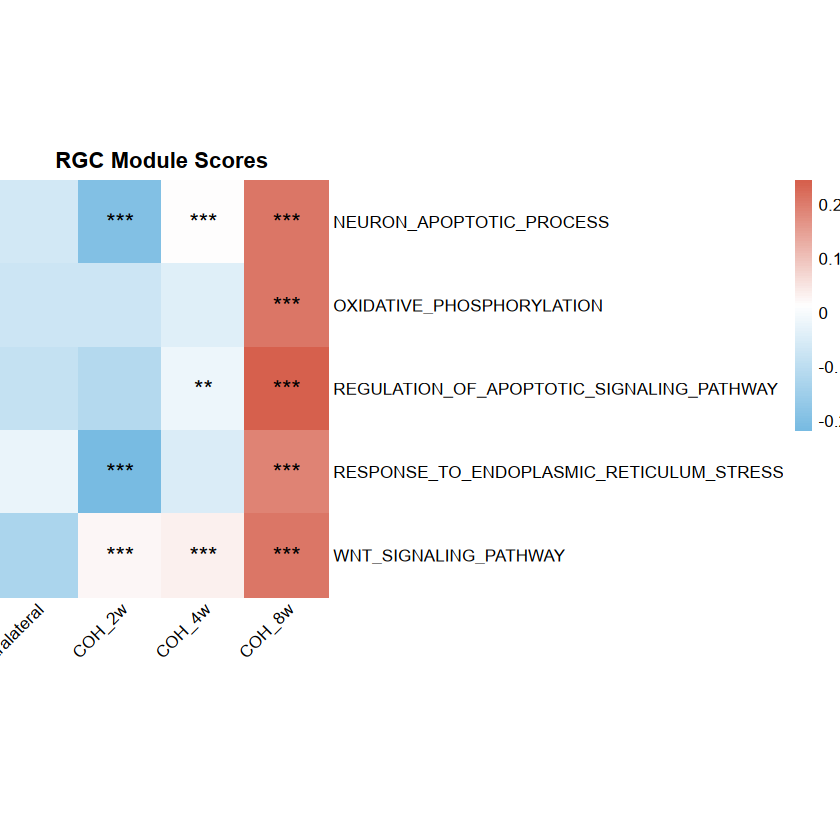

In [11]:
pheatmap(
  value_mat,
  cluster_cols = F,
  cluster_rows = F,
  color = my_color,
  display_numbers = display_mat,
  number_color = "black",
  fontsize_number = 14,
  angle_col = 45,
  main = "RGC Module Scores",
  cellwidth = 50,
  cellheight = 50,
  border_color = NA
)